In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from constants.path import CLIMATE_PATH, BARLEY_PATH


In [137]:
climate_df = pd.read_parquet(CLIMATE_PATH)
barley_df = pd.read_csv(BARLEY_PATH, sep=";")

barley_df.rename(columns={"Unnamed: 0":"code_dep"}, inplace=True)

barley_df["code_dep"] = barley_df["code_dep"].astype(str).str.strip()
barley_df["department"] = barley_df["department"].astype(str).str.strip()

barley_df["year"] = pd.to_numeric(barley_df["year"], errors="coerce")
barley_df["yield"] = pd.to_numeric(barley_df["yield"], errors="coerce")
barley_df["area"] = pd.to_numeric(barley_df["area"], errors="coerce")
barley_df["production"] = pd.to_numeric(barley_df["production"], errors="coerce")

barley_df["production"] = pd.to_numeric(barley_df["production"], errors="coerce")
barley_df["area"] = pd.to_numeric(barley_df["area"], errors="coerce")
barley_df["yield"] = pd.to_numeric(barley_df["yield"], errors="coerce")

barley_df.dropna(subset=["production", "area", "yield"], thresh=2, inplace=True)

barley_df["yield"] = barley_df["yield"].fillna(barley_df["production"] / barley_df["area"])
barley_df["production"] = barley_df["production"].fillna(barley_df["area"] * barley_df["yield"])

barley_df = barley_df.drop_duplicates()

             yield           area     production
count  3461.000000    3464.000000    3464.000000
mean      5.211611   18788.750577  110155.299519
std       1.410576   20268.445907  133033.302227
min       0.813560       0.000000       0.000000
25%       4.218820    3774.000000   17045.000000
50%       5.244440   11834.000000   56708.750000
75%       6.233790   27500.250000  152846.300000
max       9.434165  119310.000000  919249.600000


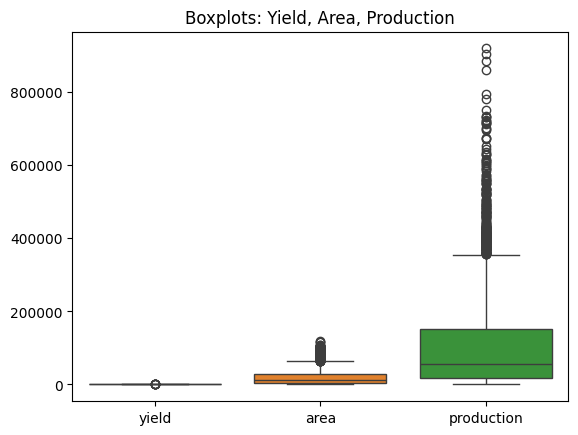

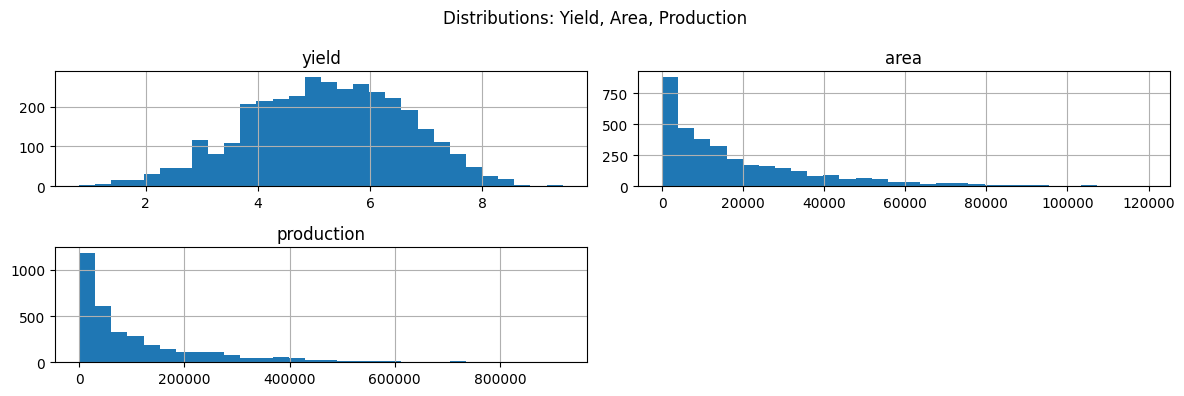

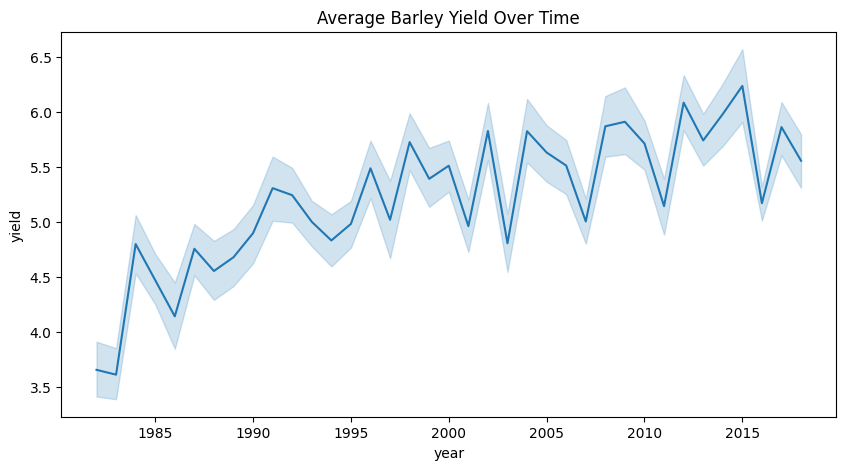

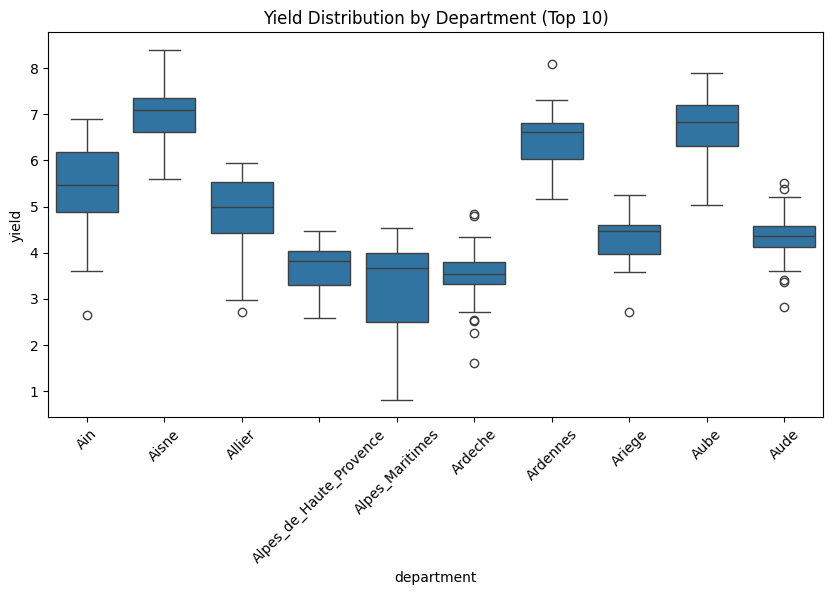

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic stats
print(barley_df[["yield", "area", "production"]].describe())

# Boxplots for outliers
plt.figure()
sns.boxplot(data=barley_df[["yield", "area", "production"]])
plt.title("Boxplots: Yield, Area, Production")
plt.show()

# Histograms
barley_df[["yield", "area", "production"]].hist(bins=30, figsize=(12, 4))
plt.suptitle("Distributions: Yield, Area, Production")
plt.tight_layout()
plt.show()

# Yield vs Year (all departments)
plt.figure(figsize=(10,5))
sns.lineplot(data=barley_df, x="year", y="yield", estimator="mean")
plt.title("Average Barley Yield Over Time")
plt.show()

# Yield by department (top 10 most frequent)
top_deps = barley_df["department"].value_counts().head(10).index
plt.figure(figsize=(10,5))
sns.boxplot(data=barley_df[barley_df["department"].isin(top_deps)], x="department", y="yield")
plt.xticks(rotation=45)
plt.title("Yield Distribution by Department (Top 10)")
plt.show()


metric
near_surface_air_temperature                  45811
precipitation                                 44844
daily_maximum_near_surface_air_temperature    44746
Name: count, dtype: int64


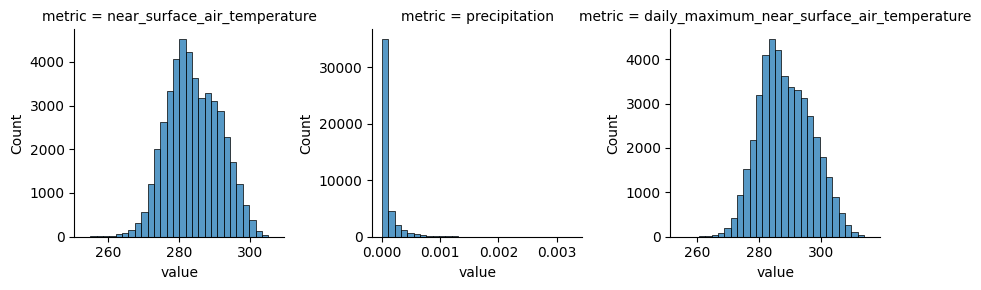

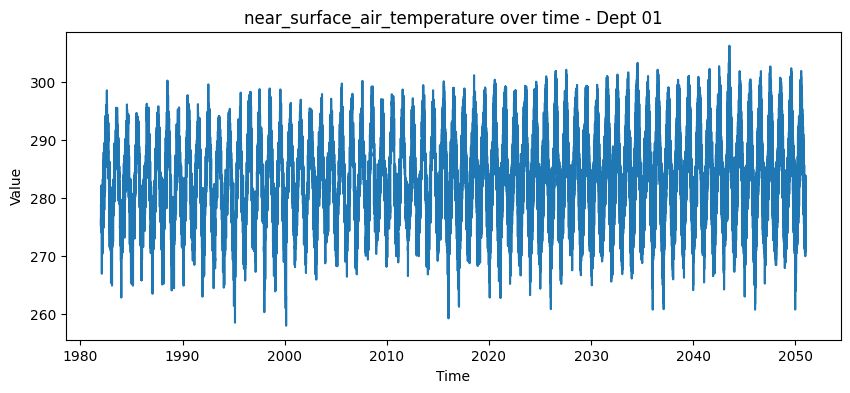

In [139]:
# Sample 1% for EDA
climate_sample = climate_df.sample(frac=0.01, random_state=42)

print(climate_sample["metric"].value_counts())

# Distribution per metric (sampled)
g = sns.FacetGrid(climate_sample, col="metric", col_wrap=3, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="value", bins=30)
plt.show()

# Time trend for one department & one metric
sample_dep = climate_df["code_dep"].iloc[0]
sample_metric = climate_df["metric"].iloc[0]

tmp = climate_df[
    (climate_df["code_dep"] == sample_dep) &
    (climate_df["metric"] == sample_metric)
].sort_values("time")

plt.figure(figsize=(10,4))
plt.plot(tmp["time"], tmp["value"])
plt.title(f"{sample_metric} over time - Dept {sample_dep}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


In [140]:
print(climate_df.columns)
print(climate_df.head())


Index(['scenario', 'nom_dep', 'code_dep', 'time', 'year', 'metric', 'value'], dtype='object')
         scenario nom_dep code_dep                time  year                        metric       value
29950  historical     Ain       01 1982-01-01 12:00:00  1982  near_surface_air_temperature  276.292267
29951  historical     Ain       01 1982-01-02 12:00:00  1982  near_surface_air_temperature  275.092407
29952  historical     Ain       01 1982-01-03 12:00:00  1982  near_surface_air_temperature  276.418518
29953  historical     Ain       01 1982-01-04 12:00:00  1982  near_surface_air_temperature  278.893372
29954  historical     Ain       01 1982-01-05 12:00:00  1982  near_surface_air_temperature  278.887207


In [141]:
import pandas as pd
import numpy as np

# --- 1) Prepare daily wide table --------------------------------------------

climate_small = climate_df[["code_dep", "year", "time", "metric", "value"]].copy()
climate_small["time"] = pd.to_datetime(climate_small["time"])

climate_wide = (
    climate_small
    .pivot_table(
        index=["code_dep", "year", "time"],
        columns="metric",
        values="value",
        aggfunc="mean"
    )
    .reset_index()
)
# Convert precip from kg/m^2/s to mm/day
climate_wide["precipitation"] = climate_wide["precipitation"] * 86400.0

print(climate_wide.head())
print("Wide climate columns:", climate_wide.columns.tolist())

# --- 2) Helper: max consecutive True in boolean series -----------------------

def max_consecutive_true(series):
    if series.isna().all():
        return 0
    s = series.fillna(False).astype(int)
    groups = (s != s.shift()).cumsum()
    return s.groupby(groups).sum().max()

# --- 3) Feature generator per (code_dep, year) -------------------------------
def climate_features_year(group):
    g = group.sort_values("time").copy()
    g["month"] = g["time"].dt.month

    feats = {}

    # --- Thresholds (Kelvin + mm) ---
    DRY_THRESH = 1.0          # mm
    HEAT_THRESH = 303.15      # 30°C in Kelvin
    FROST_THRESH = 273.15     # 0°C in Kelvin
    BASE_TEMP = 283.15        # 10°C in Kelvin for GDD

    # Columns
    tmax = g["daily_maximum_near_surface_air_temperature"]
    tmean = g["near_surface_air_temperature"]
    precip = g["precipitation"]

    # ===============================
    # Annual features (as before)
    # ===============================
    feats["tmean_mean"] = tmean.mean()
    feats["tmax_max"] = tmax.max()
    feats["tmax_p95"] = tmax.quantile(0.95)

    heat = tmax > HEAT_THRESH
    feats["heat_days"] = heat.sum()
    feats["max_consecutive_heat_days"] = max_consecutive_true(heat)

    frost = tmean < FROST_THRESH
    feats["frost_days"] = frost.sum()
    feats["max_consecutive_frost_days"] = max_consecutive_true(frost)

    feats["gdd"] = (tmean - BASE_TEMP).clip(lower=0).sum()

    feats["total_precip"] = precip.sum()
    feats["rain_days"] = (precip >= DRY_THRESH).sum()
    feats["max_1day_precip"] = precip.max()
    feats["p95_precip"] = precip.quantile(0.95)

    dry = precip < DRY_THRESH
    wet = precip >= DRY_THRESH

    feats["max_consecutive_dry_days"] = max_consecutive_true(dry)
    feats["max_consecutive_wet_days"] = max_consecutive_true(wet)

    feats["max_3day_precip_sum"] = precip.rolling(3).sum().max()
    feats["max_5day_precip_sum"] = precip.rolling(5).sum().max()
    feats["max_7day_precip_sum"] = precip.rolling(7).sum().max()

    if precip.mean() != 0:
        feats["precip_cv"] = precip.std() / precip.mean()
    else:
        feats["precip_cv"] = 0.0

    hot_dry = (tmax > HEAT_THRESH) & (precip < DRY_THRESH)
    feats["hot_dry_days"] = hot_dry.sum()
    feats["max_consecutive_hot_dry_days"] = max_consecutive_true(hot_dry)

    # ===============================
    # Seasonal features (NEW 🔥)
    # ===============================

    # --- Spring: March–May (3,4,5) ---
    spring = g[g["month"].isin([3, 4, 5])]
    if len(spring) > 0:
        tmax_s = spring["daily_maximum_near_surface_air_temperature"]
        tmean_s = spring["near_surface_air_temperature"]
        precip_s = spring["precipitation"]

        heat_s = tmax_s > HEAT_THRESH
        dry_s = precip_s < DRY_THRESH

        feats["spring_heat_days"] = heat_s.sum()
        feats["spring_max_consecutive_dry_days"] = max_consecutive_true(dry_s)
        feats["spring_gdd"] = (tmean_s - BASE_TEMP).clip(lower=0).sum()
    else:
        feats["spring_heat_days"] = 0
        feats["spring_max_consecutive_dry_days"] = 0
        feats["spring_gdd"] = 0

    # --- Summer: June–August (6,7,8) ---
    summer = g[g["month"].isin([6, 7, 8])]
    if len(summer) > 0:
        tmax_u = summer["daily_maximum_near_surface_air_temperature"]
        tmean_u = summer["near_surface_air_temperature"]
        precip_u = summer["precipitation"]

        heat_u = tmax_u > HEAT_THRESH
        dry_u = precip_u < DRY_THRESH
        hot_dry_u = heat_u & dry_u

        feats["summer_heat_days"] = heat_u.sum()
        feats["summer_hot_dry_days"] = hot_dry_u.sum()
        feats["summer_max_consecutive_dry_days"] = max_consecutive_true(dry_u)
        feats["summer_gdd"] = (tmean_u - BASE_TEMP).clip(lower=0).sum()
    else:
        feats["summer_heat_days"] = 0
        feats["summer_hot_dry_days"] = 0
        feats["summer_max_consecutive_dry_days"] = 0
        feats["summer_gdd"] = 0

    # --- Winter cold stress: Dec–Feb (12,1,2) ---
    winter = g[g["month"].isin([12, 1, 2])]
    if len(winter) > 0:
        tmean_w = winter["near_surface_air_temperature"]
        frost_w = tmean_w < FROST_THRESH
        feats["winter_frost_days"] = frost_w.sum()
    else:
        feats["winter_frost_days"] = 0

    return pd.Series(feats)


# --- 4) Build final climate feature table -----------------------------------

climate_features = (
    climate_wide
    .groupby(["code_dep", "year"], group_keys=False)
    .apply(climate_features_year)
    .reset_index()
)

print("Climate features shape:", climate_features.shape)
print(climate_features.head())


metric code_dep  year                time  daily_maximum_near_surface_air_temperature  near_surface_air_temperature  precipitation
0            01  1982 1982-01-01 12:00:00                                  279.337311                    276.292267       2.850056
1            01  1982 1982-01-02 12:00:00                                  277.687225                    275.092407      12.049969
2            01  1982 1982-01-03 12:00:00                                  278.388794                    276.418518       7.828873
3            01  1982 1982-01-04 12:00:00                                  283.519043                    278.893372       4.889469
4            01  1982 1982-01-05 12:00:00                                  281.122253                    278.887207      22.206905
Wide climate columns: ['code_dep', 'year', 'time', 'daily_maximum_near_surface_air_temperature', 'near_surface_air_temperature', 'precipitation']
Climate features shape: (6141, 30)
  code_dep  year  tmean_mean    t

/var/folders/mj/kcf7qyqx3tscrsshg63cxj380000gn/T/ipykernel_1531/4017205209.py:153: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(climate_features_year)


In [142]:
# climate_features is already created by the stress-feature pipeline

print("Climate features shape:", climate_features.shape)
print(climate_features.head())



Climate features shape: (6141, 30)
  code_dep  year  tmean_mean    tmax_max    tmax_p95  heat_days  max_consecutive_heat_days  frost_days  max_consecutive_frost_days          gdd  total_precip  rain_days  max_1day_precip  p95_precip  \
0       01  1982  282.779236  305.540894  300.051819        6.0                        6.0        30.0                         6.0  1028.895996   2375.511230      186.0        75.172569   26.323927   
1       01  1983  281.723999  302.047577  298.795422        0.0                        0.0        53.0                        14.0   875.355347   2506.673096      205.0        59.978184   27.604555   
2       01  1984  282.054199  302.437683  299.482986        0.0                        0.0        46.0                        11.0   877.436829   2400.289795      194.0        85.311668   26.460201   
3       01  1985  281.679657  301.748352  299.027185        0.0                        0.0        54.0                        13.0   886.661743   2955.386719    

In [143]:
df_merged = barley_df.merge(
    climate_features,
    on=["code_dep", "year"],
    how="left"
)

print("Merged shape:", df_merged.shape)
print(df_merged.head())


Merged shape: (3464, 34)
  code_dep department  year     yield     area  production  tmean_mean    tmax_max    tmax_p95  heat_days  max_consecutive_heat_days  frost_days  max_consecutive_frost_days          gdd  \
0       82        Ain  1982  3.950080  16065.0     63458.0  285.390411  307.236450  304.307520       28.0                        8.0         7.0                         4.0  1555.378418   
1       83        Ain  1983  2.648276  14500.0     38400.0  284.571075  301.623047  298.752411        0.0                        0.0        11.0                         6.0  1275.507812   
2       84        Ain  1984  4.822580  15500.0     74750.0  283.704163  303.142456  299.912613        0.0                        0.0        15.0                         4.0  1106.229370   
3       85        Ain  1985  4.196770  15500.0     65050.0  284.130524  306.928284  302.429260       17.0                        7.0        18.0                         6.0  1150.319580   
4       86        Ain  1986  3

In [144]:
# Fill remaining missing numeric values (from climate) with median
num_cols = df_merged.select_dtypes(include=np.number).columns

for col in num_cols:
    if col != "yield":
        df_merged[col] = df_merged[col].fillna(df_merged[col].median())

# Drop text column if not used as feature
df_model = df_merged.drop(columns=["department"])

print(df_model.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3464 entries, 0 to 3463
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   code_dep                         3464 non-null   object 
 1   year                             3464 non-null   int64  
 2   yield                            3461 non-null   float64
 3   area                             3464 non-null   float64
 4   production                       3464 non-null   float64
 5   tmean_mean                       3464 non-null   float64
 6   tmax_max                         3464 non-null   float64
 7   tmax_p95                         3464 non-null   float64
 8   heat_days                        3464 non-null   float64
 9   max_consecutive_heat_days        3464 non-null   float64
 10  frost_days                       3464 non-null   float64
 11  max_consecutive_frost_days       3464 non-null   float64
 12  gdd                 

In [145]:
df_merged[[
    "tmean_mean", "tmax_max", "gdd",
    "total_precip", "max_consecutive_dry_days",
    "heat_days", "hot_dry_days"
]].describe()


,tmean_mean,tmax_max,gdd,total_precip,max_consecutive_dry_days,heat_days,hot_dry_days
count,3464.000000,3464.000000,3464.000000,3464.000000,3464.000000,3464.000000,3464.000000
mean,283.592184,304.741565,1092.371811,2087.428130,17.503176,6.007506,5.508372
std,0.058344,0.101792,9.479785,98.724939,0.221866,0.475141,0.470393
min,281.756195,301.623047,881.457092,600.767700,15.000000,0.000000,0.000000
25%,283.592575,304.740829,1092.243713,2085.511658,17.500000,6.000000,5.500000
50%,283.592575,304.740829,1092.243713,2085.511658,17.500000,6.000000,5.500000
75%,283.592575,304.740829,1092.243713,2085.511658,17.500000,6.000000,5.500000
max,285.390411,307.562012,1555.378418,5771.318359,29.000000,28.000000,27.000000


In [152]:
df_merged.head()

,code_dep,department,year,yield,area,production,tmean_mean,tmax_max,tmax_p95,heat_days,max_consecutive_heat_days,frost_days,max_consecutive_frost_days,gdd,total_precip,rain_days,max_1day_precip,p95_precip,max_consecutive_dry_days,max_consecutive_wet_days,max_3day_precip_sum,max_5day_precip_sum,max_7day_precip_sum,precip_cv,hot_dry_days,max_consecutive_hot_dry_days,spring_heat_days,spring_max_consecutive_dry_days,spring_gdd,summer_heat_days,summer_hot_dry_days,summer_max_consecutive_dry_days,summer_gdd,winter_frost_days,yield_detrended
0,82,Ain,1982,3.950080,16065.0,63458.0,285.390411,307.236450,304.307520,28.0,8.0,7.0,4.0,1555.378418,1280.321777,148.0,39.687233,19.156416,15.0,13.0,87.636016,104.137618,121.243339,1.912932,27.0,8.0,0.0,6.0,109.988312,25.0,24.0,15.0,996.346924,7.0,NaN
1,83,Ain,1983,2.648276,14500.0,38400.0,284.571075,301.623047,298.752411,0.0,0.0,11.0,6.0,1275.507812,5402.088867,167.0,287.663055,81.219388,18.0,11.0,526.129074,711.897232,931.631519,2.284557,0.0,0.0,0.0,7.0,147.487915,0.0,0.0,8.0,808.706177,11.0,NaN
2,84,Ain,1984,4.822580,15500.0,74750.0,283.704163,303.142456,299.912613,0.0,0.0,15.0,4.0,1106.229370,2004.181030,139.0,81.852135,29.364357,17.0,7.0,147.607868,250.399890,270.571880,2.255763,0.0,0.0,0.0,8.0,117.357849,0.0,0.0,12.0,784.489868,15.0,NaN
3,85,Ain,1985,4.196770,15500.0,65050.0,284.130524,306.928284,302.429260,17.0,7.0,18.0,6.0,1150.319580,1927.781738,179.0,67.368889,24.670422,15.0,10.0,125.092955,189.725088,224.429426,1.829463,17.0,7.0,0.0,7.0,50.702209,7.0,7.0,14.0,692.038696,18.0,NaN
4,86,Ain,1986,3.598450,12900.0,46420.0,283.864990,303.623077,300.390112,2.0,2.0,15.0,3.0,1056.628662,2166.842285,167.0,70.194908,29.146518,17.0,14.0,122.803064,163.715903,193.108396,1.887431,2.0,2.0,0.0,6.0,65.988983,2.0,2.0,17.0,753.785828,9.0,NaN


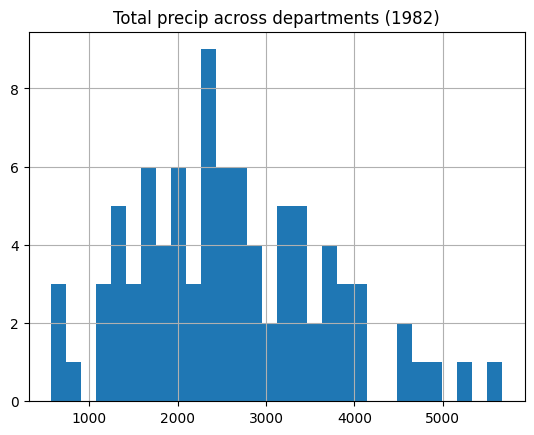

In [146]:
import matplotlib.pyplot as plt

climate_features[climate_features["year"] == 1982]["total_precip"].hist(bins=30)
plt.title("Total precip across departments (1982)")
plt.show()


In [147]:
df_merged.corr(numeric_only=True)["yield"].sort_values()


max_7day_precip_sum               -0.026118
max_3day_precip_sum               -0.025849
max_5day_precip_sum               -0.025837
max_1day_precip                   -0.024709
p95_precip                        -0.020815
gdd                               -0.020101
total_precip                      -0.018645
precip_cv                         -0.017405
summer_gdd                        -0.016343
hot_dry_days                      -0.011607
max_consecutive_heat_days         -0.010299
max_consecutive_hot_dry_days      -0.010299
heat_days                         -0.010116
tmean_mean                        -0.008386
tmax_p95                          -0.008003
summer_hot_dry_days               -0.006572
summer_heat_days                  -0.004722
spring_max_consecutive_dry_days   -0.004526
rain_days                         -0.004468
max_consecutive_frost_days        -0.004267
spring_gdd                        -0.004209
winter_frost_days                 -0.002961
frost_days                      

In [148]:
import numpy as np

# simple linear detrend
coef = np.polyfit(df_merged["year"], df_merged["yield"], 1)
trend = np.polyval(coef, df_merged["year"])
df_merged["yield_detrended"] = df_merged["yield"] - trend

df_merged.corr(numeric_only=True)["yield_detrended"].sort_values()


year                              NaN
yield                             NaN
area                              NaN
production                        NaN
tmean_mean                        NaN
tmax_max                          NaN
tmax_p95                          NaN
heat_days                         NaN
max_consecutive_heat_days         NaN
frost_days                        NaN
max_consecutive_frost_days        NaN
gdd                               NaN
total_precip                      NaN
rain_days                         NaN
max_1day_precip                   NaN
p95_precip                        NaN
max_consecutive_dry_days          NaN
max_consecutive_wet_days          NaN
max_3day_precip_sum               NaN
max_5day_precip_sum               NaN
max_7day_precip_sum               NaN
precip_cv                         NaN
hot_dry_days                      NaN
max_consecutive_hot_dry_days      NaN
spring_heat_days                  NaN
spring_max_consecutive_dry_days   NaN
spring_gdd  

In [149]:
print(climate_features.columns.tolist())


['code_dep', 'year', 'tmean_mean', 'tmax_max', 'tmax_p95', 'heat_days', 'max_consecutive_heat_days', 'frost_days', 'max_consecutive_frost_days', 'gdd', 'total_precip', 'rain_days', 'max_1day_precip', 'p95_precip', 'max_consecutive_dry_days', 'max_consecutive_wet_days', 'max_3day_precip_sum', 'max_5day_precip_sum', 'max_7day_precip_sum', 'precip_cv', 'hot_dry_days', 'max_consecutive_hot_dry_days', 'spring_heat_days', 'spring_max_consecutive_dry_days', 'spring_gdd', 'summer_heat_days', 'summer_hot_dry_days', 'summer_max_consecutive_dry_days', 'summer_gdd', 'winter_frost_days']


In [150]:
import numpy as np

# Fill remaining missing numeric values with median
num_cols = df_merged.select_dtypes(include=np.number).columns

for col in num_cols:
    if col not in ["yield", "yield_detrended"]:
        df_merged[col] = df_merged[col].fillna(df_merged[col].median())


# Drop text / non-feature columns
df_model = df_merged.drop(columns=["department"])

# Sanity checks
print(df_model.info())
print(df_model.isna().sum().sort_values(ascending=False).head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3464 entries, 0 to 3463
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   code_dep                         3464 non-null   object 
 1   year                             3464 non-null   int64  
 2   yield                            3461 non-null   float64
 3   area                             3464 non-null   float64
 4   production                       3464 non-null   float64
 5   tmean_mean                       3464 non-null   float64
 6   tmax_max                         3464 non-null   float64
 7   tmax_p95                         3464 non-null   float64
 8   heat_days                        3464 non-null   float64
 9   max_consecutive_heat_days        3464 non-null   float64
 10  frost_days                       3464 non-null   float64
 11  max_consecutive_frost_days       3464 non-null   float64
 12  gdd                 

In [ ]:
out_path = "../data/processed/barley_climate_model_ready.csv"
df_model.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Final shape:", df_model.shape)


OSError: Cannot save file into a non-existent directory: '../data/processed'

#### Deprioritise low yield, yield is going to reduce in 10 yrs, prioritise high yield with hgh area, look at decreasing area

#